In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*_when.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WHEN_MODEL_OUTPUT_DIR = OUTPUT_DIR / "xgboost_when"
WHEN_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEVICE = "cuda:0"
SECONDS_PER_HOUR = 60 * 60

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

REGRESSION_SUMMARY_FILENAME = "regression_summary_XGBoost.csv"

In [3]:
csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h_when")),
)
csv_file_path = csv_files[4]

csv_file_path, csv_files

(PosixPath('output/dataset_winsize3h_when.csv'),
 [PosixPath('output/dataset_winsize0.25h_when.csv'),
  PosixPath('output/dataset_winsize0.5h_when.csv'),
  PosixPath('output/dataset_winsize1h_when.csv'),
  PosixPath('output/dataset_winsize2h_when.csv'),
  PosixPath('output/dataset_winsize3h_when.csv'),
  PosixPath('output/dataset_winsize4h_when.csv'),
  PosixPath('output/dataset_winsize5h_when.csv'),
  PosixPath('output/dataset_winsize6h_when.csv'),
  PosixPath('output/dataset_winsize7h_when.csv'),
  PosixPath('output/dataset_winsize8h_when.csv'),
  PosixPath('output/dataset_winsize9h_when.csv'),
  PosixPath('output/dataset_winsize10h_when.csv'),
  PosixPath('output/dataset_winsize11h_when.csv'),
  PosixPath('output/dataset_winsize12h_when.csv')])

In [4]:
df = pd.read_csv(csv_file_path)
df = df.loc[~df["is_bg"]].drop(columns="is_bg")

print(f"\nReading {csv_file_path}")


Reading output/dataset_winsize3h_when.csv


# Stage1: Obtain optimal window size

In [5]:
import numpy as np
from xgboost import XGBRegressor

TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLD = -1
regression_target = "label_time_to_event_seconds"


def _as_numpy(values):
    if hasattr(values, "get") and not isinstance(values, (pd.Series, pd.DataFrame)):
        values = values.get()
    return np.asarray(values, dtype=float)


def mae_loss(y_true, y_pred):
    return float(np.mean(np.abs(_as_numpy(y_true) - _as_numpy(y_pred))))


def middle_quartile_mae_loss(y_true, y_pred):
    absolute_errors = np.abs(_as_numpy(y_true) - _as_numpy(y_pred))
    lower_quartile = np.quantile(absolute_errors, 0.25)
    # lower_quartile = np.quantile(absolute_errors, 0.00)
    upper_quartile = np.quantile(absolute_errors, 0.75)
    middle_errors = absolute_errors[
        (absolute_errors >= lower_quartile) & (absolute_errors <= upper_quartile)
    ]
    return float(np.mean(middle_errors))


xgboost_window_models = []
xgboost_window_test_losses = []
xgboost_window_middle_quartile_test_losses = []
WINDOW_MODEL_OUTPUT_DIR = WHEN_MODEL_OUTPUT_DIR / "window_models"
WINDOW_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for dataset_path in tqdm(csv_files):
    dataset_df = pd.read_csv(dataset_path)
    dataset_df = dataset_df.loc[~dataset_df["is_bg"]].drop(columns="is_bg")
    train_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
    test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

    X_train = train_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_train = X_train.select_dtypes(include=["number", "bool"])
    y_train = train_df[regression_target].astype(float)
    train_mask = y_train.notna()
    X_train = X_train.loc[train_mask]
    y_train = y_train.loc[train_mask]

    X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_test = X_test.select_dtypes(include=["number", "bool"])
    y_test = test_df[regression_target].astype(float)
    test_mask = y_test.notna()
    X_test = X_test.loc[test_mask]
    y_test = y_test.loc[test_mask]

    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
    )
    model.fit(X_train, y_train)
    model_path = WINDOW_MODEL_OUTPUT_DIR / f"{dataset_path.stem}.json"
    model.save_model(model_path)

    y_pred = model.predict(X_test)
    test_loss = mae_loss(y_test, y_pred)
    middle_quartile_test_loss = middle_quartile_mae_loss(y_test, y_pred)

    xgboost_window_models.append(model)
    xgboost_window_test_losses.append(test_loss)
    xgboost_window_middle_quartile_test_losses.append(middle_quartile_test_loss)

    print(
        f"{dataset_path.name}: "
        f"test MAE={test_loss:.6f}, "
        f"middle-50% MAE={middle_quartile_test_loss:.6f}; "
        f"saved model to {model_path}"
    )

xgboost_window_test_losses, xgboost_window_middle_quartile_test_losses

  0%|          | 0/14 [00:00<?, ?it/s]/home/aj/venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [18:35:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
  7%|▋         | 1/14 [00:00<00:05,  2.18it/s]

dataset_winsize0.25h_when.csv: test MAE=404.831799, middle-50% MAE=275.925688; saved model to model_outputs/xgboost_when/window_models/dataset_winsize0.25h_when.json


 21%|██▏       | 3/14 [00:00<00:02,  3.89it/s]

dataset_winsize0.5h_when.csv: test MAE=393.180232, middle-50% MAE=281.084994; saved model to model_outputs/xgboost_when/window_models/dataset_winsize0.5h_when.json
dataset_winsize1h_when.csv: test MAE=391.820568, middle-50% MAE=277.781233; saved model to model_outputs/xgboost_when/window_models/dataset_winsize1h_when.json


 36%|███▌      | 5/14 [00:01<00:01,  4.73it/s]

...

 93%|█████████▎| 13/14 [00:02<00:00,  5.27it/s]

dataset_winsize10h_when.csv: test MAE=415.377572, middle-50% MAE=297.545984; saved model to model_outputs/xgboost_when/window_models/dataset_winsize10h_when.json
dataset_winsize11h_when.csv: test MAE=415.803775, middle-50% MAE=295.809597; saved model to model_outputs/xgboost_when/window_models/dataset_winsize11h_when.json


100%|██████████| 14/14 [00:02<00:00,  4.79it/s]

dataset_winsize12h_when.csv: test MAE=420.247270, middle-50% MAE=290.436943; saved model to model_outputs/xgboost_when/window_models/dataset_winsize12h_when.json


([404.831798758558,
  393.1802318942162,
  391.820568289808,
  414.5324699647965,
  412.81882796748994,
  421.68831298171835,
  418.4994890766759,
  420.3070933024089,
  421.0962930494739,
  419.7324036628969,
  415.84053531769786,
  415.37757209039506,
  415.80377500800677,
  420.2472698252688],
 [275.9256884700172,
  281.08499424431915,
  277.78123277233493,
  295.70596740066367,
  296.8735587827621,
  301.3935015278478,
  299.3188095913138,
  301.1883359519384,
  300.1425589284589,
  297.60033687468496,
  298.6539190148795,
  297.54598408360636,
  295.8095970563991,
  290.4369431362357])

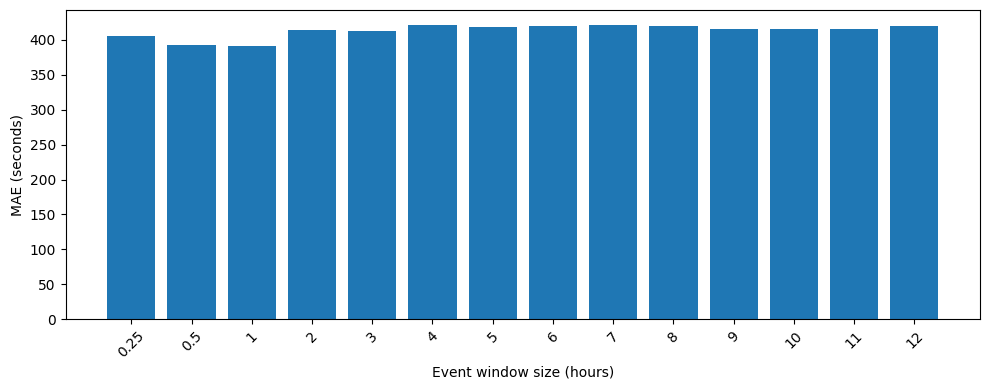

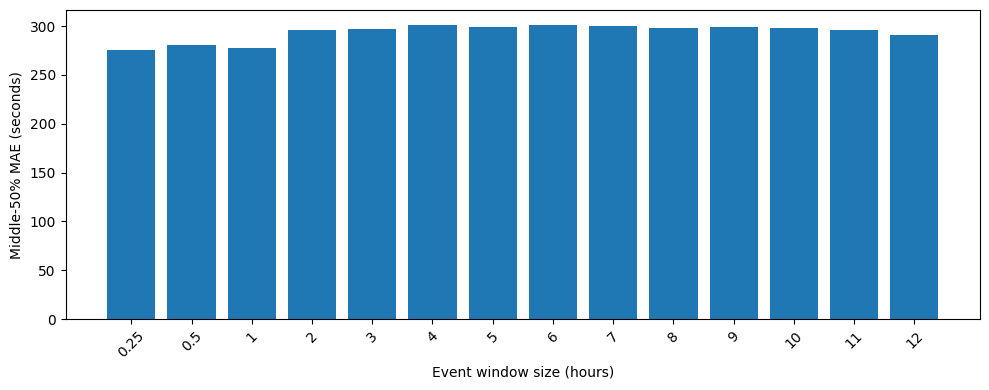

In [6]:
import matplotlib.pyplot as plt

window_sizes = [
    path.stem.split("winsize", 1)[1].removesuffix("h_when") for path in csv_files
]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, xgboost_window_test_losses)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE (seconds)")
# plt.title("XGBoost MAE by event window size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_mae_by_event_window_size.pdf", dpi=300)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, xgboost_window_middle_quartile_test_losses)
plt.xlabel("Event window size (hours)")
plt.ylabel("Middle-50% MAE (seconds)")
# plt.title("XGBoost middle-50% MAE by event window size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_middle50_mae_by_event_window_size.pdf", dpi=300)
plt.show()

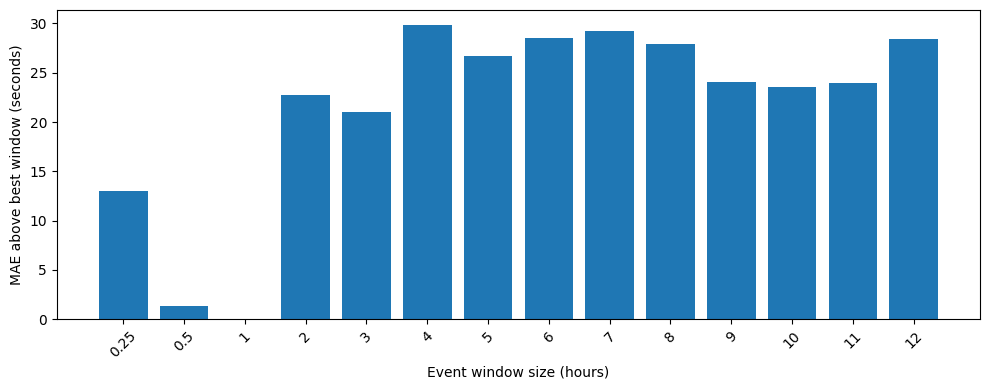

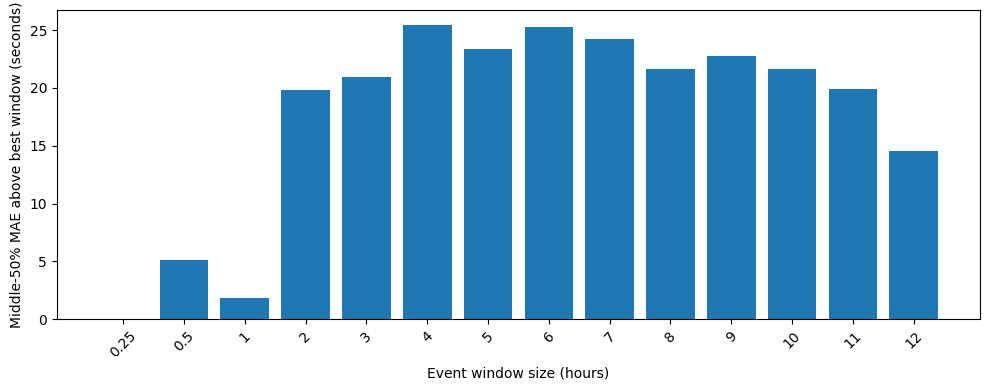

In [7]:
best_loss = min(xgboost_window_test_losses)
loss_above_best = [loss - best_loss for loss in xgboost_window_test_losses]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, loss_above_best)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE above best window (seconds)")
# plt.title(f"XGBoost MAE above best window; best = {best_loss:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_mae_above_best_window.pdf", dpi=300)
plt.show()

best_middle_quartile_loss = min(xgboost_window_middle_quartile_test_losses)
middle_quartile_loss_above_best = [
    loss - best_middle_quartile_loss
    for loss in xgboost_window_middle_quartile_test_losses
]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, middle_quartile_loss_above_best)
plt.xlabel("Event window size (hours)")
plt.ylabel("Middle-50% MAE above best window (seconds)")
# plt.title(
#     "XGBoost middle-50% MAE above best window; "
#     f"best = {best_middle_quartile_loss:.2f}s"
# )
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_middle50_mae_above_best_window.pdf", dpi=300)
plt.show()

# stage 2: Search parameters


Don't forget to set `OPTIMAL_WINDOW_HOURS` in accordance with the above experiment.

In [8]:
import json

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBRegressor

# Optimal window from stage 1.
OPTIMAL_WINDOW_HOURS = 1
optimal_dataset_path = DATA_DIR / f"dataset_winsize{OPTIMAL_WINDOW_HOURS:g}h_when.csv"

GRID_SEARCH_OUTPUT_DIR = (
    OUTPUT_DIR / f"xgboost_gridcv_winsize{OPTIMAL_WINDOW_HOURS:g}h_when"
)
GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REFIT_METRIC = "neg_mean_absolute_error"
GRID_N_JOBS = 1
GRID_VERBOSE = 2

XGB_N_ESTIMATORS_VALUES = [100, 300]
XGB_LEARNING_RATE_VALUES = [0.03, 0.1]
XGB_MAX_DEPTH_VALUES = [3, 5]
XGB_MIN_CHILD_WEIGHT_VALUES = [1, 5]
XGB_SUBSAMPLE_VALUES = [0.8, 1.0]

xgb_param_grid = {
    "n_estimators": XGB_N_ESTIMATORS_VALUES,
    "learning_rate": XGB_LEARNING_RATE_VALUES,
    "max_depth": XGB_MAX_DEPTH_VALUES,
    "min_child_weight": XGB_MIN_CHILD_WEIGHT_VALUES,
    "subsample": XGB_SUBSAMPLE_VALUES,
}

dataset_df = pd.read_csv(optimal_dataset_path)
dataset_df = dataset_df.loc[~dataset_df["is_bg"]].drop(columns="is_bg")
trainval_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

X_trainval = trainval_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_trainval = trainval_df[regression_target].astype(float)
trainval_mask = y_trainval.notna()
X_trainval = X_trainval.loc[trainval_mask]
y_trainval = y_trainval.loc[trainval_mask]
cv = PredefinedSplit(trainval_df.loc[trainval_mask, "fold_id"].to_numpy())

X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_test = test_df[regression_target].astype(float)
test_mask = y_test.notna()
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

xgb_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    param_grid=xgb_param_grid,
    scoring={
        "neg_mean_absolute_error": "neg_mean_absolute_error",
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    refit=REFIT_METRIC,
    cv=cv,
    n_jobs=GRID_N_JOBS,
    verbose=GRID_VERBOSE,
    return_train_score=True,
)

xgb_grid_search.fit(X_trainval, y_trainval)
xgb_grid_model_path = WHEN_MODEL_OUTPUT_DIR / "xgboost_grid_search_best.json"
xgb_grid_search.best_estimator_.save_model(xgb_grid_model_path)

xgb_cv_results = pd.DataFrame(xgb_grid_search.cv_results_)
xgb_cv_results.to_csv(GRID_SEARCH_OUTPUT_DIR / "xgboost_cv_results.csv", index=False)

xgb_y_pred = xgb_grid_search.predict(X_test)
xgb_test_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_test_rmse = mean_squared_error(y_test, xgb_y_pred) ** 0.5
xgb_test_r2 = r2_score(y_test, xgb_y_pred)

xgb_best_params = {
    "refit_metric": REFIT_METRIC,
    "best_cv_mae": float(-xgb_grid_search.best_score_),
    "test_mae": float(xgb_test_mae),
    "test_rmse": float(xgb_test_rmse),
    "test_r2": float(xgb_test_r2),
    "best_params": xgb_grid_search.best_params_,
}
(GRID_SEARCH_OUTPUT_DIR / "xgboost_best_params.json").write_text(
    json.dumps(xgb_best_params, indent=4)
)

xgb_test_predictions = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": xgb_y_pred,
        "absolute_error": np.abs(y_test.to_numpy() - xgb_y_pred),
    }
)
xgb_test_predictions.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_test_predictions.csv",
    index=False,
)

xgb_gridcv_summary = pd.DataFrame([xgb_best_params])
xgb_gridcv_summary.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_gridcv_summary.csv",
    index=False,
)

print(f"Best CV MAE: {-xgb_grid_search.best_score_:.6f}")
print(f"Test MAE: {xgb_test_mae:.6f}")
print(f"Best params: {xgb_grid_search.best_params_}")
print(f"Saved best grid-search model to {xgb_grid_model_path}")

xgb_gridcv_summary

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.0

,refit_metric,best_cv_mae,test_mae,test_rmse,test_r2,best_params
0,neg_mean_absolute_error,392.691169,392.405304,554.808515,0.930253,"{'learning_rate': 0.03, 'max_depth': 5, 'min_c..."


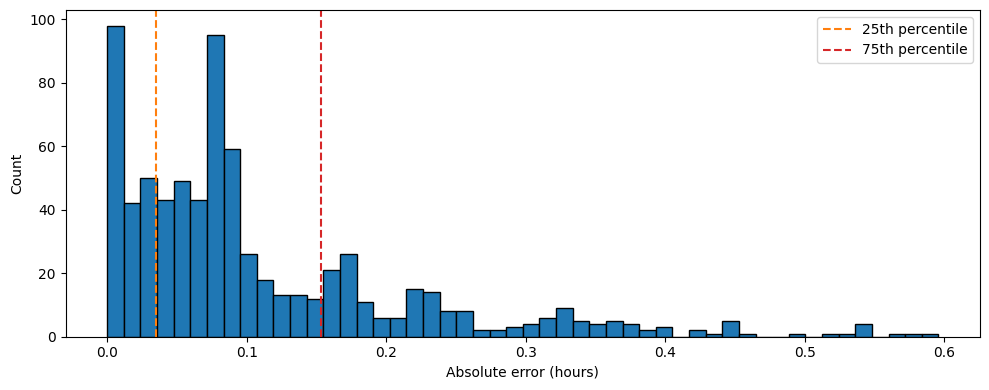

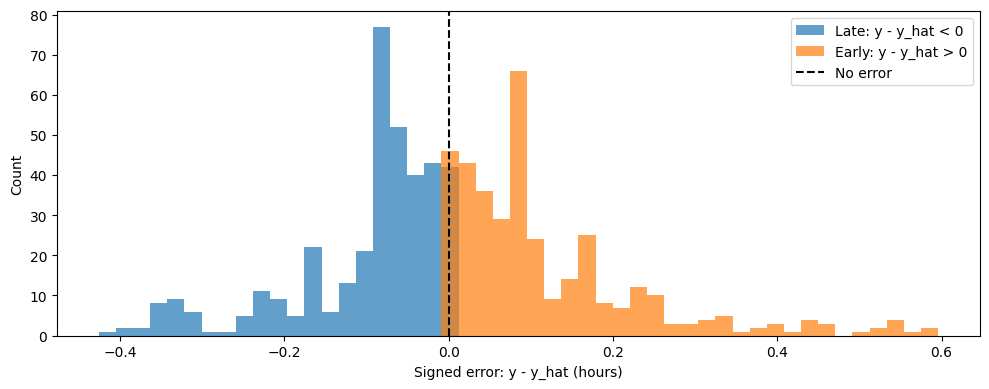

Middle-50% MAE: 284.249415 seconds
Middle-50% MAE: 4.737490 minutes


In [9]:
import matplotlib.pyplot as plt
import numpy as np

absolute_errors = xgb_test_predictions["absolute_error"]
lower_quartile = absolute_errors.quantile(0.25)
upper_quartile = absolute_errors.quantile(0.75)
middle_quartile_errors = absolute_errors[
    absolute_errors.between(lower_quartile, upper_quartile, inclusive="both")
]
middle_quartile_mae = middle_quartile_errors.mean()
absolute_errors_hours = absolute_errors / SECONDS_PER_HOUR
lower_quartile_hours = lower_quartile / SECONDS_PER_HOUR
upper_quartile_hours = upper_quartile / SECONDS_PER_HOUR

plt.figure(figsize=(10, 4))
plt.hist(absolute_errors_hours, bins=50, edgecolor="black")
plt.axvline(
    lower_quartile_hours, color="tab:orange", linestyle="--", label="25th percentile"
)
plt.axvline(
    upper_quartile_hours, color="tab:red", linestyle="--", label="75th percentile"
)
plt.xlabel("Absolute error (hours)")
plt.ylabel("Count")
# plt.title("XGBoost absolute error distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_absolute_error_distribution.pdf", dpi=300)
plt.show()

signed_errors = xgb_test_predictions["y_true"] - xgb_test_predictions["y_pred"]
signed_errors_hours = signed_errors / SECONDS_PER_HOUR
early_errors_hours = signed_errors_hours[signed_errors_hours > 0]
late_errors_hours = signed_errors_hours[signed_errors_hours < 0]
signed_error_bins_hours = np.linspace(
    signed_errors_hours.min(), signed_errors_hours.max(), 50
)

plt.figure(figsize=(10, 4))
plt.hist(
    late_errors_hours,
    bins=signed_error_bins_hours,
    alpha=0.7,
    label="Late: y - y_hat < 0",
)
plt.hist(
    early_errors_hours,
    bins=signed_error_bins_hours,
    alpha=0.7,
    label="Early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)")
plt.ylabel("Count")
# plt.title("XGBoost signed error distribution: early vs late predictions")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_signed_error_distribution.pdf", dpi=300)
plt.show()

print(f"Middle-50% MAE: {middle_quartile_mae:.6f} seconds")
print(f"Middle-50% MAE: {middle_quartile_mae / 60:.6f} minutes")

# Train weighted model

In [10]:
LATE_PREDICTION_PENALTY = 15.0


def late_penalty_squared_error(y_true, y_pred):
    residual = y_pred - y_true
    weights = np.where(residual > 0, LATE_PREDICTION_PENALTY, 1.0)
    grad = 2.0 * weights * residual
    hess = 2.0 * weights
    return grad, hess


late_penalty_xgb_model = XGBRegressor(
    objective=late_penalty_squared_error,
    eval_metric="mae",
    tree_method="hist",
    device=DEVICE,
    n_jobs=1,
    random_state=RANDOM_STATE,
    **xgb_grid_search.best_params_,
)
late_penalty_xgb_model.fit(X_trainval, y_trainval)
late_penalty_model_path = WHEN_MODEL_OUTPUT_DIR / "xgboost_late_penalty.json"
late_penalty_xgb_model.save_model(late_penalty_model_path)

late_penalty_y_pred = late_penalty_xgb_model.predict(X_test)
late_penalty_signed_errors = y_test.to_numpy() - late_penalty_y_pred
late_penalty_absolute_errors = np.abs(late_penalty_signed_errors)
late_prediction_mask = late_penalty_signed_errors < 0
early_prediction_mask = late_penalty_signed_errors > 0

late_weighted_absolute_errors = np.where(
    late_prediction_mask,
    LATE_PREDICTION_PENALTY * late_penalty_absolute_errors,
    late_penalty_absolute_errors,
)

late_penalty_metrics = {
    "mae": mean_absolute_error(y_test, late_penalty_y_pred),
    "late_penalized_mae": late_weighted_absolute_errors.mean(),
    "rmse": mean_squared_error(y_test, late_penalty_y_pred) ** 0.5,
    "r2": r2_score(y_test, late_penalty_y_pred),
    "late_prediction_rate": late_prediction_mask.mean(),
    "early_prediction_rate": early_prediction_mask.mean(),
    "late_prediction_penalty": LATE_PREDICTION_PENALTY,
    "best_params": xgb_grid_search.best_params_,
}

late_penalty_test_predictions = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": late_penalty_y_pred,
        "signed_error": late_penalty_signed_errors,
        "absolute_error": late_penalty_absolute_errors,
        "late_weighted_absolute_error": late_weighted_absolute_errors,
        "is_late_prediction": late_prediction_mask,
    }
)

print(f"MAE: {late_penalty_metrics['mae']:.6f} seconds")
print(
    "Late-penalized MAE "
    f"(late predictions x{LATE_PREDICTION_PENALTY:g}): "
    f"{late_penalty_metrics['late_penalized_mae']:.6f} seconds"
)
print(f"Late prediction rate: {late_penalty_metrics['late_prediction_rate']:.6%}")
print(f"Early prediction rate: {late_penalty_metrics['early_prediction_rate']:.6%}")
print(f"Saved late-penalty model to {late_penalty_model_path}")

late_penalty_metrics

MAE: 466.862377 seconds
Late-penalized MAE (late predictions x15): 1266.376369 seconds
Late prediction rate: 36.290323%
Early prediction rate: 63.709677%
Saved late-penalty model to model_outputs/xgboost_when/xgboost_late_penalty.json


{'mae': 466.8623770989718,
 'late_penalized_mae': np.float64(1266.3763687045023),
 'rmse': 706.817974609942,
 'r2': 0.8867973117350298,
 'late_prediction_rate': np.float64(0.3629032258064516),
 'early_prediction_rate': np.float64(0.6370967741935484),
 'late_prediction_penalty': 15.0,
 'best_params': {'learning_rate': 0.03,
  'max_depth': 5,
  'min_child_weight': 1,
  'n_estimators': 300,
  'subsample': 1.0}}

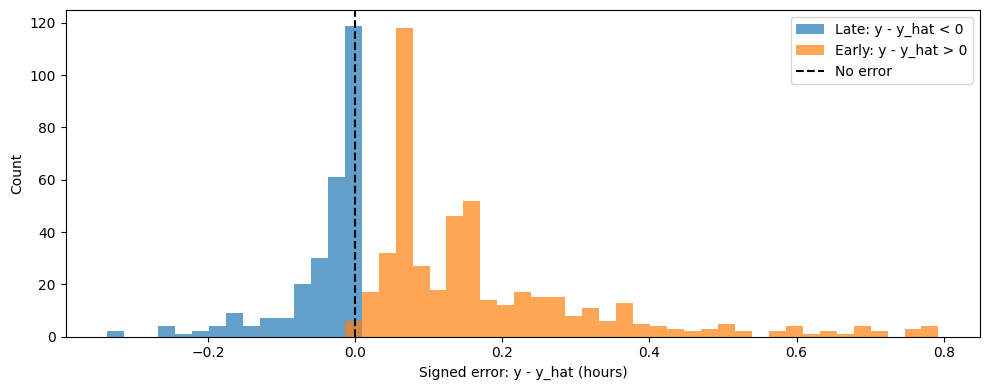

Unweighted model late prediction rate: 50.537634%
Unweighted model early prediction rate: 49.462366%
Weighted model late prediction rate: 36.290323%
Weighted model early prediction rate: 63.709677%
Unweighted model middle-50% MAE: 284.249415 seconds (4.737490 minutes)
Weighted model middle-50% MAE: 317.248204 seconds (5.287470 minutes)


In [11]:
unweighted_signed_errors = (
    xgb_test_predictions["y_true"] - xgb_test_predictions["y_pred"]
)
weighted_signed_errors = late_penalty_test_predictions["signed_error"]
weighted_early_errors = weighted_signed_errors[weighted_signed_errors > 0]
weighted_late_errors = weighted_signed_errors[weighted_signed_errors < 0]
weighted_absolute_errors = late_penalty_test_predictions["absolute_error"]
unweighted_absolute_errors = xgb_test_predictions["absolute_error"]


def middle_quartile_mae(errors):
    lower_quartile = errors.quantile(0.25)
    upper_quartile = errors.quantile(0.75)
    middle_errors = errors[
        errors.between(lower_quartile, upper_quartile, inclusive="both")
    ]
    return middle_errors.mean()


unweighted_middle_quartile_mae = middle_quartile_mae(unweighted_absolute_errors)
weighted_middle_quartile_mae = middle_quartile_mae(weighted_absolute_errors)
weighted_signed_errors_hours = weighted_signed_errors / SECONDS_PER_HOUR
weighted_early_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours > 0
]
weighted_late_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours < 0
]
weighted_signed_error_bins_hours = np.linspace(
    weighted_signed_errors_hours.min(),
    weighted_signed_errors_hours.max(),
    50,
)

plt.figure(figsize=(10, 4))
plt.hist(
    weighted_late_errors_hours,
    bins=weighted_signed_error_bins_hours,
    alpha=0.7,
    label="Late: y - y_hat < 0",
)
plt.hist(
    weighted_early_errors_hours,
    bins=weighted_signed_error_bins_hours,
    alpha=0.7,
    label="Early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)")
plt.ylabel("Count")
# plt.title("Late-penalized XGBoost signed error distribution")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "late_penalized_xgboost_signed_error_distribution.pdf", dpi=300
)
plt.show()

print(
    f"Unweighted model late prediction rate: "
    f"{(unweighted_signed_errors < 0).mean():.6%}"
)
print(
    f"Unweighted model early prediction rate: "
    f"{(unweighted_signed_errors > 0).mean():.6%}"
)
print(f"Weighted model late prediction rate: {(weighted_signed_errors < 0).mean():.6%}")
print(
    f"Weighted model early prediction rate: {(weighted_signed_errors > 0).mean():.6%}"
)
print(
    f"Unweighted model middle-50% MAE: "
    f"{unweighted_middle_quartile_mae:.6f} seconds "
    f"({unweighted_middle_quartile_mae / 60:.6f} minutes)"
)
print(
    f"Weighted model middle-50% MAE: "
    f"{weighted_middle_quartile_mae:.6f} seconds "
    f"({weighted_middle_quartile_mae / 60:.6f} minutes)"
)